# **1. Imports**

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms as T
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchvision.models as models
import wandb

# **3. Dataset Preparation**

### **3.1 Class for images**

In [46]:
class ImageDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
            
        return image, label

### **3.2 Data augmentation**

In [47]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform_tl = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(30),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transform_tl = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

### **3.3 Report of the dataset**

In [48]:

data_dir = Path('Breast-Cancer-Dataset')
classes = [d.name for d in data_dir.iterdir() if d.is_dir()]
label_map = {name: i for i, name in enumerate(classes)}
num_classes = len(classes)

print(f"Found classes: {label_map}")

file_paths = []
labels = []
for class_name, label_idx in label_map.items():
    class_dir = data_dir / class_name
    for img_path in class_dir.glob('*.[jp][pn]g'): 
        file_paths.append(str(img_path))
        labels.append(label_idx)

print(f"Total images found: {len(file_paths)}")

Found classes: {'benign': 0, 'malignant': 1, 'normal': 2}
Total images found: 780


### **3.4 Train-Test Split**

In [49]:

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, 
    labels, 
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_dataset_tl = ImageDataset(train_paths, train_labels, transform=train_transform_tl)
val_dataset_tl   = ImageDataset(val_paths,   val_labels,   transform=val_transform_tl)

BATCH_SIZE = 32
train_loader_tl = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=BATCH_SIZE, shuffle=False)

print(f"[TL] Training images: {len(train_dataset_tl)}")
print(f"[TL] Validation images: {len(val_dataset_tl)}")

[TL] Training images: 624
[TL] Validation images: 156


# **4. Training and Validation**

### **4.1 Wandb Login**

We will use [**Weights and Biases'**](https://wandb.ai/site/) visualization to analyze various metrics and also load different models. It is **necessary** to add your own *WANDB_API_KEY*.

In [ ]:
wandb.login(key="")

### **4.2 Device**

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


### **4.3 Balance Classes' Weights**

Since our BUSI Dataset is imbalanced we will fix this by adding more weight to the minority class

In [52]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

### **4.4 Transfer Learning Model**

In this case we will be using

In [53]:
wandb.init(
    project="BUSI-TRANSFER-LEARNING",
    name="Transfer-Learning-ResNet18",
    config={
        "architecture": "ResNet18-TL",
        "dataset": "Breast-Cancer",
        "epochs": 50,
        "learning_rate": 0.002,
        "weight_decay": 0.0006,
        "patience": 8,
        "num_classes": 3
    }
)

config = wandb.config

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Freeze ALL layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only layer4 + fc
for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, config.num_classes)

model = model.to(device)

learning_rate = config.learning_rate
NUM_EPOCHS = config.epochs

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    [
        {"params": model.fc.parameters(), "lr": 1e-3},
        {"params": model.layer4.parameters(), "lr": 1e-4},
    ],
    weight_decay=config.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=config.patience,
    factor=0.1
)

wandb.config.update({"class_weights": class_weights.cpu().numpy().tolist()})

### **4.5 Training and Validation loop**

In [54]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_loss = float('inf')
best_val_acc = 0
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    # ----------- TRAIN -----------
    model.train()
    train_loss_sum = 0
    correct_train = 0
    n_train_samples = 0

    for images, labels in train_loader_tl:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        n_train_samples += labels.size(0)
        correct_train += (pred == labels).sum().item()

    train_loss = train_loss_sum / n_train_samples
    train_acc = 100 * correct_train / n_train_samples

    # ----------- VALIDATION -----------
    model.eval()
    val_loss_sum = 0
    correct_val = 0
    n_val_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader_tl:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            n_val_samples += labels.size(0)
            correct_val += (pred == labels).sum().item()

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / n_val_samples
    val_acc = 100 * correct_val / n_val_samples

    scheduler.step(val_loss)

    # Save to history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"[{epoch+1}/{NUM_EPOCHS}] Train Loss={train_loss:.4f}  Val Loss={val_loss:.4f} "
          f"| Train Acc={train_acc:.2f}%  Val Acc={val_acc:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })

    # ---------- EARLY STOPPING ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "best_tl.pth")
        print("  ✓ New best model saved.")

    else:
        patience_counter += 1
        if patience_counter >= config.patience:
            print("⛔ Early stopping.")
            break


# ====================== FINAL EVALUATION ======================
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = outputs.max(1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=all_labels,
        preds=all_preds,
        class_names=["benign", "malignant", "normal"]
    )
})

wandb.finish()

[1/50] Train Loss=0.8613  Val Loss=0.6157 | Train Acc=58.01%  Val Acc=75.64%
  ✓ New best model saved.
[2/50] Train Loss=0.5570  Val Loss=0.6477 | Train Acc=74.52%  Val Acc=81.41%
[3/50] Train Loss=0.4148  Val Loss=0.4316 | Train Acc=82.05%  Val Acc=82.69%
  ✓ New best model saved.
[4/50] Train Loss=0.3915  Val Loss=0.3944 | Train Acc=85.26%  Val Acc=81.41%
  ✓ New best model saved.
[5/50] Train Loss=0.3858  Val Loss=0.4593 | Train Acc=82.05%  Val Acc=83.33%
[6/50] Train Loss=0.2993  Val Loss=0.5027 | Train Acc=86.70%  Val Acc=81.41%
[7/50] Train Loss=0.2192  Val Loss=0.4176 | Train Acc=92.47%  Val Acc=86.54%
[8/50] Train Loss=0.2482  Val Loss=0.4025 | Train Acc=89.26%  Val Acc=88.46%
[9/50] Train Loss=0.2085  Val Loss=0.4308 | Train Acc=90.87%  Val Acc=88.46%
[10/50] Train Loss=0.1853  Val Loss=0.3316 | Train Acc=92.63%  Val Acc=89.74%
  ✓ New best model saved.
[11/50] Train Loss=0.1123  Val Loss=0.3701 | Train Acc=95.67%  Val Acc=89.74%
[12/50] Train Loss=0.1384  Val Loss=0.4159 | Tr

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▄▅▆▅▆▇▇▇▇█▇█▇█▇███████
train/loss,█▅▄▄▄▃▂▃▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▄▄▅▄▆▇▇██▆▇██▇▆█▇█▇▆█
val/loss,▇█▃▃▄▅▃▃▃▁▂▃▃▂▁▅▆▃▃▆▆▄▄
epoch,23
lr,0.001
train/accuracy,96.47436
train/loss,0.08787
val/accuracy,89.10256


### **5. Loading and Visualization of Model**


Loading the best saved model...


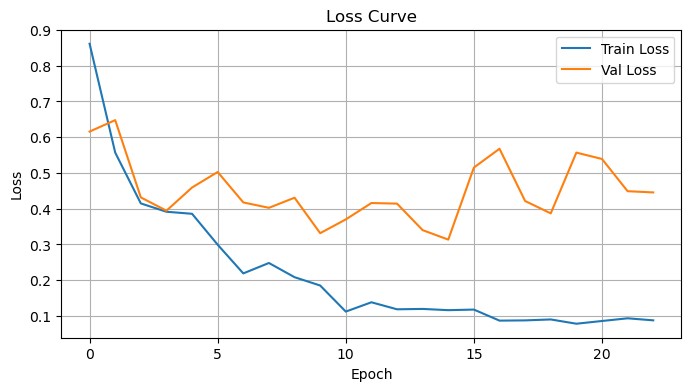

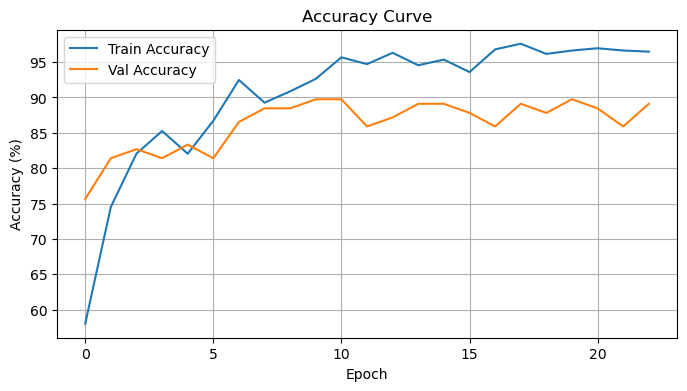

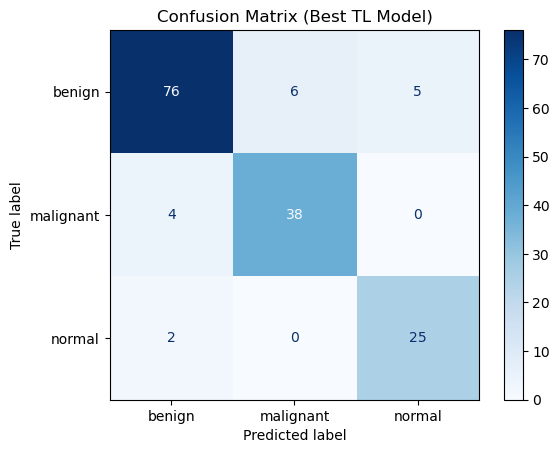

In [55]:
print("\nLoading the best saved model...")
best_model = models.resnet18(weights=None)  
best_model.fc = nn.Linear(num_features, num_classes)
best_model.load_state_dict(torch.load("best_tl.pth"))
best_model = best_model.to(device)
best_model.eval()

# -------- COLLECT PREDICTIONS --------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, pred = outputs.max(1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ===================== LOSS & ACCURACY PLOTS =====================

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.legend(); plt.grid(True); plt.show()

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Best TL Model)")
plt.show()
